## AISE4010- Assignment2 - Time Series Forecasting using CNN, RNN, LSTM and GRU

## Grade: 100 points

### Instructions

#### Follow These Steps before submitting your assignment 

1. Complete the notebook.

2. Make sure all plots have axis labels.

3. Once the notebook is complete, `Restart` your kernel by clicking 'Kernel' > 'Restart & Run All'.

4. Fix any errors until your notebook runs without any problems.

5. Submit one completed notebook for the group to OWL by the deadline.

6. Make sure to reference all external code and documentation used.

### Dataset

The `StockData.csv` represents a time series dataset designed to simulate the behavior of stock prices over a period of 1000 days, starting from January 1, 2023. This dataset includes key features commonly found in stock market data, such as opening prices, closing prices, daily highs, daily lows, and trading volume. 

Features:
- Date: The timestamp representing the specific day for each record.
- Open: The stock's price at the start of the trading day. 
- High: The highest price of the stock during the trading day. It is generally higher than the opening price, reflecting intraday market movements.
- Low: The lowest price of the stock during the trading day. It is usually lower than the opening price, capturing downward movements in the market.
- Close: The stock’s price at the end of the trading day. This price reflects the market's closing valuation and fluctuates within a range close to the opening price.
- Volume: The number of shares traded during the day.

### Question 1 - Data Preprocessing (15%)
- Q1.1 Load the provided dataset and plot the `Closing prices` time series. (5%)
- Q1.2 (5%): 

  - a) Decompose the time series into its components and explain them.  
  - b) What do the trend and seasonality components tell you about the overall behavior of the time series? How does understanding     these components help in selecting a model for time series forecasting?
- Q1.3 Restructure the time series using a sliding window approach (with size 10) to prepare it for supervised learning. Split the `Closing prices` time series into 80% for training and 20% for testing. (5%)


                  Open        High        Low       Close  Volume
Date                                                             
2023-01-01  102.483571  105.911957  99.423692  106.579055    1132
2023-01-02   99.708883  108.134328  93.337217  100.398438    3838
2023-01-03  104.038482  109.522783  94.684843  106.660228    3696
2023-01-04  108.814281  110.507805  99.452025  111.932348    4385
2023-01-05  100.426345  101.953304  96.349198   98.844836    4770


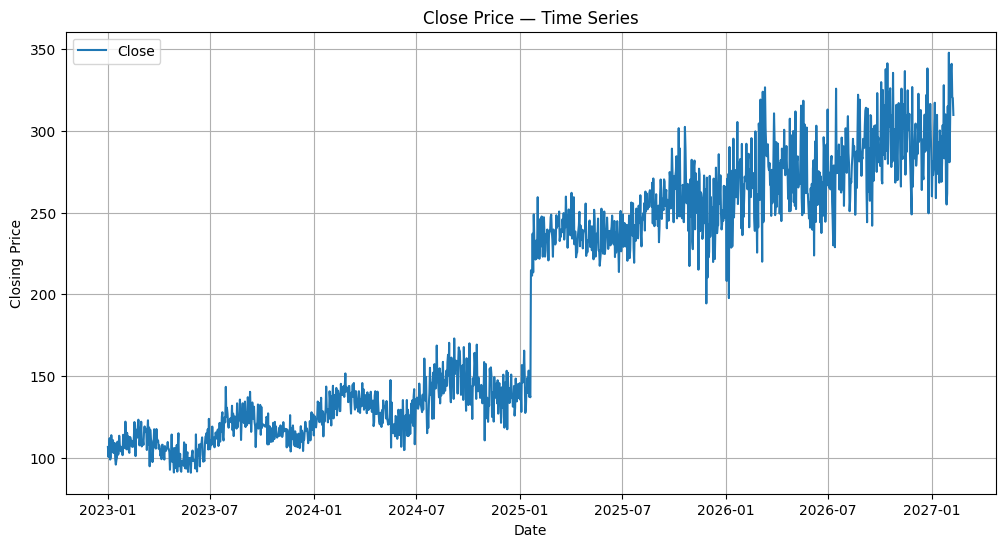

In [1]:
# Q1.1:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset 
df = pd.read_csv('StockData.csv', index_col='Date', parse_dates=True)
print(df.head())

# Plot
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Close')
plt.title('Close Price — Time Series')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.legend()
plt.show()

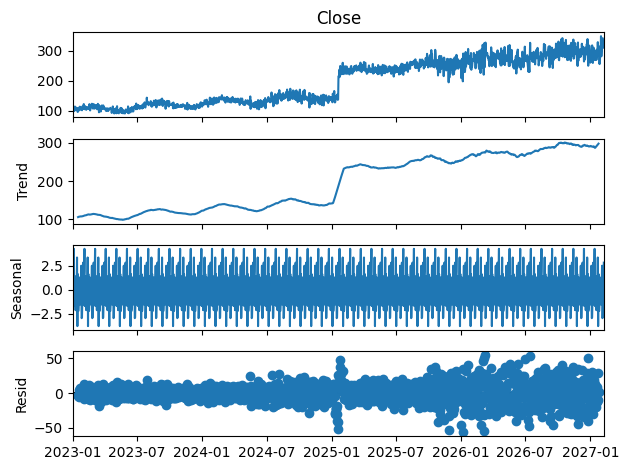

In [2]:
# Q1.2 a)
from statsmodels.tsa.seasonal import seasonal_decompose
results = seasonal_decompose(df["Close"], model='additive', period=30) #30 for monthly
results.plot();

*Write your Answer to Q1.2-b here:*

In [3]:
# Q1.3
import numpy as np

data = df["Close"].values
window_size = 10

# Create sliding window dataset
def sliding_window(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = sliding_window(data, window_size)

# Split into 80% training and 20% testing
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("Testing shape:", y_test.shape)

Training samples: 1192
Testing samples: 298
Testing shape: (298,)


### Question2 - 1D Convolutional Neural Network (CNN) (20%)
- Q2.1 Create a 1D CNN model for time series forecasting. The model should have two convolutional layers of size 64 and 32 and kernel size of 3, fully connected layer of size 50, droup out of 0.3, and ReLU activation. Train the model using the provided dataset for 50 epochs. Use the batch_size of 32, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q2.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series. (6%)
- Q2.3 How does the 1D-CNN perform in terms of capturing short-term dependencies? Based on the RMSE and MAE values, do you think this model can effectively capture long-term trends? Why or why not? (2%)


c:\Users\Alexis\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 9218.1836 - val_loss: 1266.8356
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 1420.9867 - val_loss: 428.3195
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 993.0801 - val_loss: 475.0170
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 913.9258 - val_loss: 419.6574
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 898.6288 - val_loss: 482.8532
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 866.6578 - val_loss: 486.3640
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 818.4410 - val_loss: 487.7932
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 795.8419 - val_loss: 549.0723
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 777.5853 - val_loss: 422.6882
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 805.4755 - val_loss: 444.5348
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 727.1104 - val_loss: 418.0466
Epoch 12/50
30/3

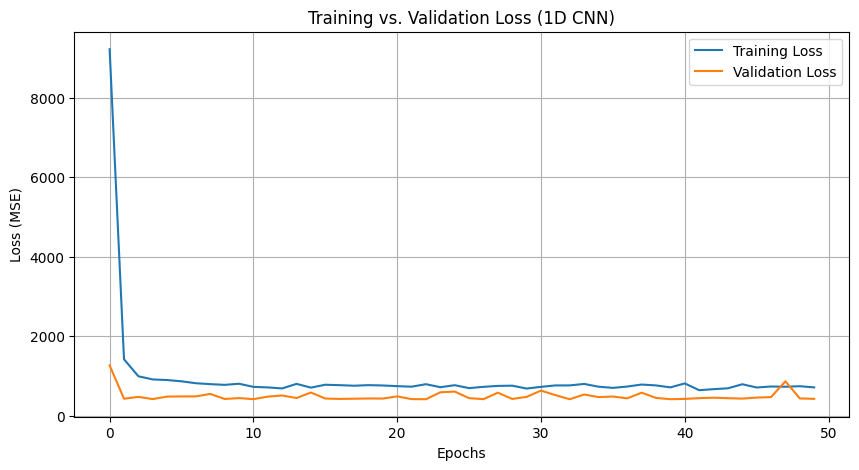

In [4]:
# Q2.1
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

# Reshape input for CNN: (samples, timesteps, features)
X_train_CNN = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_CNN = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Create a 1D CNN model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_CNN.shape[1], 1)),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

model.compile(optimizer=Adam(), loss='mse')

# Train the model
history = model.fit(
    X_train_CNN, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot the Training Loss and the Validation Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs. Validation Loss (1D CNN)")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

RMSE=22.039, MAE=17.789


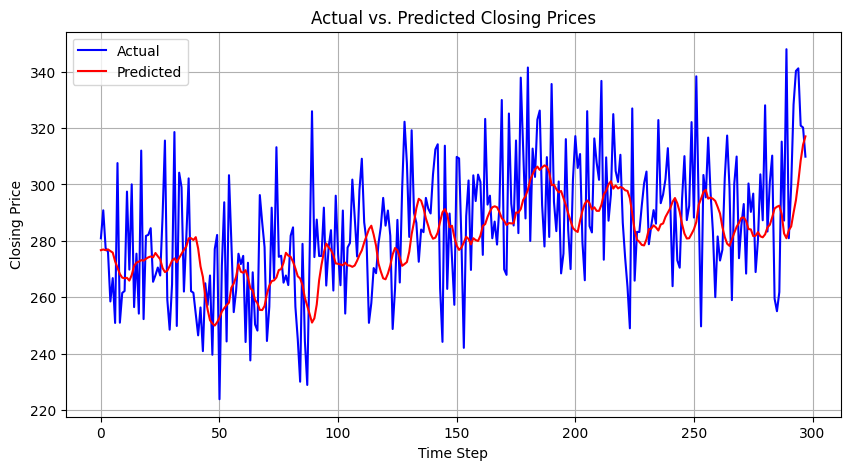

In [5]:
# Q2.2
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

y_pred_CNN = model.predict(X_test_CNN, verbose=0).ravel()

rmse_CNN = sqrt(mean_squared_error(y_test, y_pred_CNN))
mae_CNN  = mean_absolute_error(y_test, y_pred_CNN)
print(f"RMSE={rmse_CNN:.3f}, MAE={mae_CNN:.3f}")

# Plot our Predictions vs Actual Values
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual", color="blue")
plt.plot(y_pred_CNN, label="Predicted", color="red")
plt.title("Actual vs. Predicted Closing Prices")
plt.xlabel("Time Step")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

*Write your Answer to Q2.3 Here:*


### Question 3 - Recurrent Neural Networks (RNN) (20%)
- Q3.1 Create an RNN model for time series forecasting. The model should include a SimpleRNN layer of size 40 and ReLU activation. Train the model using the provided dataset for 50 epochs. Use the batch_size of 16, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q3.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series. (6%)
- Q3.3 Why did we use a smaller batch size compared to CNN model. Why might RNN struggle with long-term dependencies, and how is this reflected in the evaluation metrics? (2%)


Epoch 1/50


c:\Users\Alexis\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 901.3736 - val_loss: 498.1752
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 95.8629 - val_loss: 529.7202
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 103.9520 - val_loss: 496.5891
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 94.9868 - val_loss: 506.3866
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 94.9877 - val_loss: 498.0802
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 96.9991 - val_loss: 493.0749
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 95.9522 - val_loss: 494.7101
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 95.1211 - val_loss: 495.8187
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 98.3776 - val_loss: 487.5029
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 96.7606 - val_loss: 484.2816
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 95.3615 - val_loss: 489.5733
Epoch 12/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 

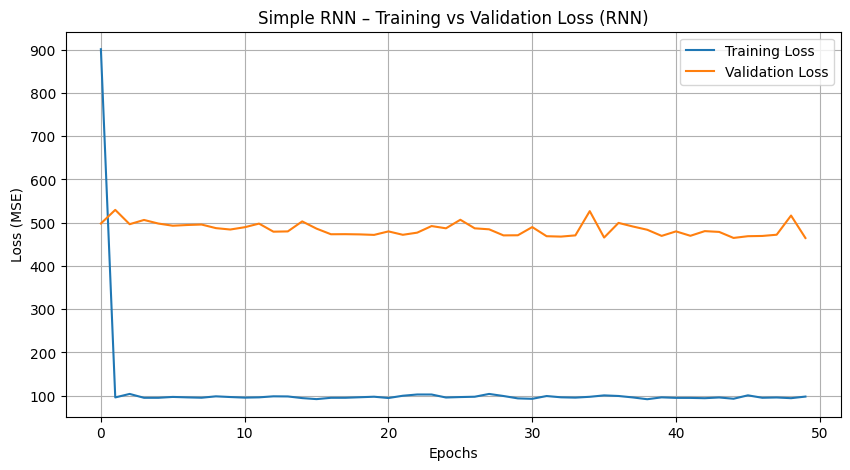

In [6]:
# Q3.1
from tensorflow.keras.layers import SimpleRNN

X_train_RNN = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_RNN  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

# Build the RNN model
model_RNN = Sequential([
    SimpleRNN(40, activation='relu', input_shape=(X_train_RNN.shape[1], 1)),
    Dense(1) 
])
model_RNN.compile(optimizer=Adam(), loss='mse')

# Train the model
history_RNN = model_RNN.fit(
    X_train_RNN, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Plot the Training Loss and the Validation Loss
plt.figure(figsize=(10,5))
plt.plot(history_RNN.history['loss'], label='Training Loss')
plt.plot(history_RNN.history['val_loss'], label='Validation Loss')
plt.title("Simple RNN – Training vs Validation Loss (RNN)")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

RMSE=22.039, MAE=17.789


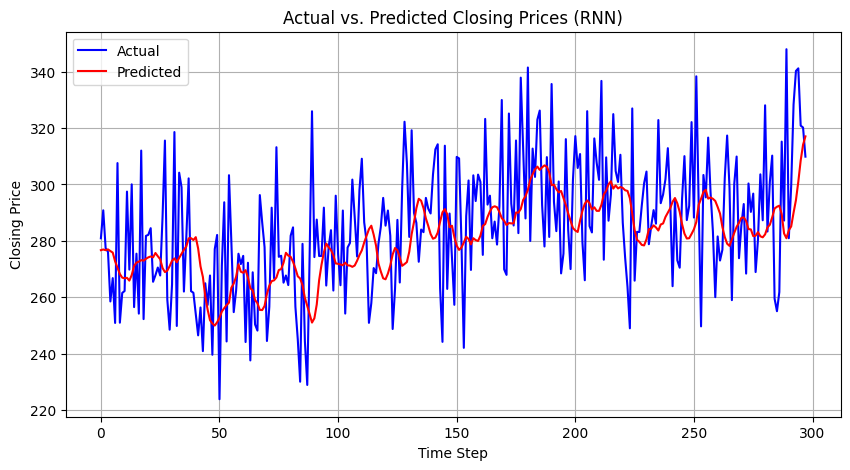

In [7]:
# Q3.2
y_pred_RNN = model.predict(X_test_RNN, verbose=0).ravel()

rmse_RNN = sqrt(mean_squared_error(y_test, y_pred_RNN))
mae_RNN  = mean_absolute_error(y_test, y_pred_RNN)
print(f"RMSE={rmse_RNN:.3f}, MAE={mae_RNN:.3f}")

plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual", color="blue")
plt.plot(y_pred_RNN, label="Predicted", color="red")
plt.title("Actual vs. Predicted Closing Prices (RNN)")
plt.xlabel("Time Step")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

*Write your Answer to Q3.3 Here:*

### Question 4 - Long Short-Term Memory (LSTM) (20%)
- Q4.1 Create an LSTM model for time series forecasting.The model should include two LSTM layers of size 100 and 50, and ReLU activation. Train the model using the provided dataset for 100 epochs. Use the batch_size of 16, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q4.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series. (6%)
- Q4.3 Why do we use a larger epoch compared to RNN? (2%)

Epoch 1/100


c:\Users\Alexis\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 4771.8828 - mae: 41.8311 - val_loss: 438.1160 - val_mae: 16.3894
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 115.9099 - mae: 7.3489 - val_loss: 453.3006 - val_mae: 16.5874
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 115.3958 - mae: 7.4220 - val_loss: 483.1006 - val_mae: 17.2197
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 109.8914 - mae: 7.1760 - val_loss: 438.2886 - val_mae: 16.1193
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 111.7204 - mae: 7.3410 - val_loss: 445.0597 - val_mae: 16.3687
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 109.1768 - mae: 7.2143 - val_loss: 448.6657 - val_mae: 16.3680
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 109.2893 - mae: 7.3326 - val_loss: 556.8882 - val_mae: 18.5803
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 110.3899 - mae: 7.4317 - val_loss: 452.4178 - val_mae: 16.3725
Epoch 9/100
60/60 ━━━━━━━━

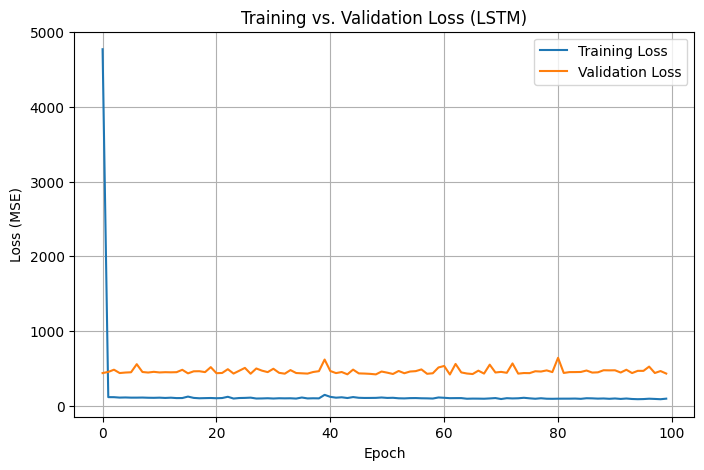

In [8]:
# Q4.1
from tensorflow.keras.layers import LSTM

X_train_LSTM = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_LSTM = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

model_LSTM = Sequential([
    LSTM(100, activation = 'relu', return_sequences =True, input_shape=(10, 1)),
    LSTM(50, activation = 'relu'),
    Dense(1)
])

model_LSTM.compile(optimizer=Adam(), loss='mse', metrics=['mae'])

history_LSTM = model_LSTM.fit (
    X_train_LSTM, 
    y_train, 
    epochs = 100, 
    batch_size = 16, 
    validation_split=0.2, 
    verbose=1
)

plt.figure(figsize=(8,5))
plt.plot(history_LSTM.history['loss'], label='Training Loss')
plt.plot(history_LSTM.history['val_loss'], label='Validation Loss')
plt.title('Training vs. Validation Loss (LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

RMSE=22.039, MAE=17.789


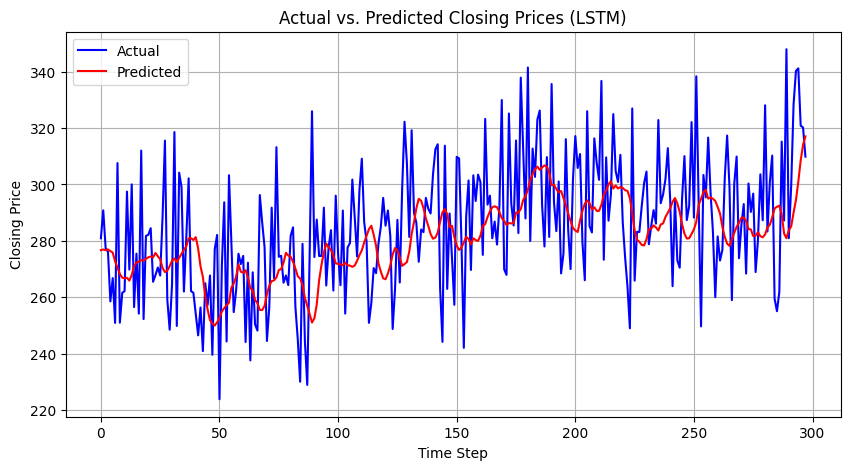

In [9]:
# Q4.2
y_pred_LSTM = model.predict(X_test_LSTM, verbose=0).ravel()

rmse_LSTM = sqrt(mean_squared_error(y_test, y_pred_LSTM))
mae_LSTM  = mean_absolute_error(y_test, y_pred_LSTM)
print(f"RMSE={rmse_LSTM:.3f}, MAE={mae_LSTM:.3f}")

# Plot actual vs. predicted values
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual", color="blue")
plt.plot(y_pred_LSTM, label="Predicted", color="red",)
plt.title("Actual vs. Predicted Closing Prices (LSTM)")
plt.xlabel("Time Step")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

*Write your Answer to Q4.3 Here:*

### Question 5 - Gated Recurrent Unit (GRU) (20%)
- Q5.1 Create a GRU model for time series forecasting.The model should include two GRU layers of size 80 and 40, and ReLU activation. Train the model using the provided dataset for 100 epochs. Use the batch_size of 16, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q5.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series.(6%)
- Q5.3 How does the GRU compare to LSTM in terms of computational efficiency and forecasting performance? (2%)

Epoch 1/100


c:\Users\Alexis\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 7568.5337 - val_loss: 460.9954
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 92.2141 - val_loss: 459.7606
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 92.7554 - val_loss: 443.0821
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 91.9561 - val_loss: 447.5876
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 90.8963 - val_loss: 447.9413
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 91.4527 - val_loss: 445.7461
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 92.6573 - val_loss: 451.0023
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 92.1012 - val_loss: 476.7044
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 100.2443 - val_loss: 456.2973
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 94.2667 - val_loss: 459.8354
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 91.5063 - val_loss: 459.4107
Epoch 12/100
60/60 ━━━━━━━━━

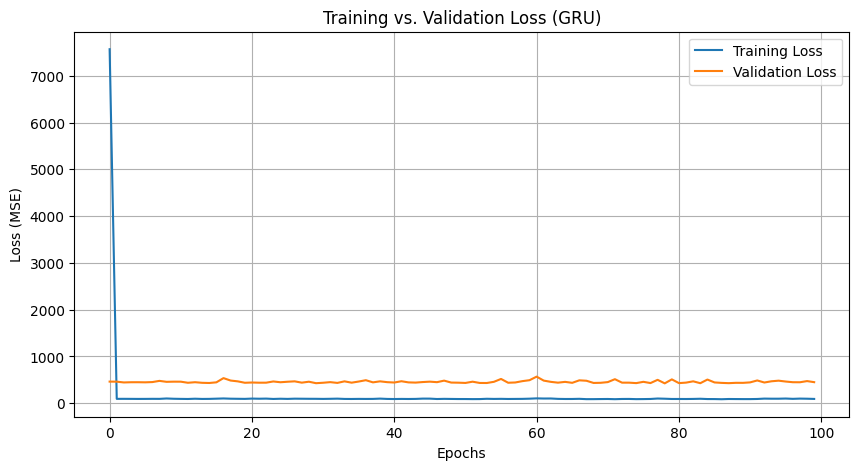

In [10]:
# Q5.1
from tensorflow.keras.layers import GRU

X_train_GRU = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_GRU  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

# Build the GRU model
model_GRU = Sequential([
    GRU(80, activation='relu', return_sequences=True, input_shape=(X_train_GRU.shape[1], 1)),
    GRU(40, activation='relu'),
    Dense(1)
])
model_GRU.compile(optimizer=Adam(), loss='mse')

# Train the model
history_GRU = model_GRU.fit(
    X_train_GRU, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Plot training vs validation loss
plt.figure(figsize=(10,5))
plt.plot(history_GRU.history['loss'], label='Training Loss')
plt.plot(history_GRU.history['val_loss'], label='Validation Loss')
plt.title("Training vs. Validation Loss (GRU)")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

RMSE=22.039, MAE=17.789


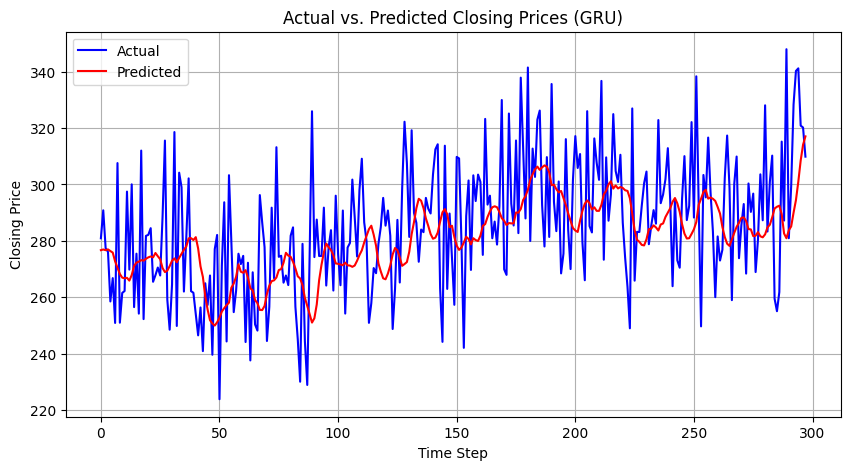

In [11]:
# Q5.2
y_pred_GRU = model.predict(X_test_GRU, verbose=0).ravel()

rmse_GRU = sqrt(mean_squared_error(y_test, y_pred_GRU))
mae_GRU  = mean_absolute_error(y_test, y_pred_GRU)
print(f"RMSE={rmse_GRU:.3f}, MAE={mae_GRU:.3f}")

# Plot actual vs. predicted values
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual", color="blue")
plt.plot(y_pred_GRU, label="Predicted", color="red",)
plt.title("Actual vs. Predicted Closing Prices (GRU)")
plt.xlabel("Time Step")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

*Write your Answer to Q5.3 Here:*

### Question 6 - Discussion (5%)
- Q6.1 Compare the performance of 1D-CNN, RNN, LSTM, and GRU models based on training and test execution time, performance (RMSE and MAE), and potential overfitting/underfitting. (3%)
- Q6.2 Discuss in which cases you would prefer using 1D-CNN vs LSTM or GRU for time series data. (2%)


*Write your Answer to Q6.2 Here:*